In [8]:
"""
Generate monthly climatologies for dissolved iron concentrations, isotopic composition
and ligand speciation from BAIT (Bermuda Atlantic Iron Time‑series) datasets.

This module supports two related datasets published by BCO‑DMO:

1. ``bottle and isotopic iron`` measurements (dataset 936824).  The file contains
   dissolved iron concentrations and stable isotope ratios collected on BAIT
   cruises, reported for both GO‑FLO bottle samples and near‑surface boat‑pump
   samples.  Each measurement has an associated quality flag.  Only flag values
   of 1 (good) or 2 (probably good) are retained; other values are masked.
2. ``iron speciation`` measurements (dataset 869081).  This file contains
   dissolved iron concentrations and the concentrations and conditional stability
   constants of up to two classes of organic ligands (L1 and L2).  Ligand
   measurements have accompanying quality flags; as above, only flags 1–2 are
   retained.

Given CSV inputs for these datasets, the functions in this module will:

* Parse the sampling date to determine calendar month.
* Snap sample depths to a user‑defined depth grid within a specified tolerance.
* Apply quality flags to the relevant variables and convert values to numeric.
* Group the data by month and depth and compute the mean for each variable.
* Return an :class:`xarray.Dataset` with dimensions ``month`` and ``depth`` and
  variables corresponding to the iron concentration, isotopic composition and
  ligand properties.  Missing combinations of month, depth or variable are
  represented with ``NaN`` so that all variables share the same coordinate grid.

Example usage::

    from bait_iron_climatology import build_bait_iron_climatology

    ds = build_bait_iron_climatology(
        '936824_v1_bait_dissolved_fe_and_isotopes.csv',
        'dataset_buckcaprara_bait_fespeciation-1.csv'
    )
    print(ds)
    ds.to_netcdf('bait_iron_monthly_climatology.nc')

The default depth grid spans 0–2000 m at 10 m resolution.  You may supply a
custom grid (e.g. matching the BATS climatologies) by passing a ``depth_grid``
array to :func:`build_bait_iron_climatology`.

"""

from __future__ import annotations

import warnings
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [9]:
# Default depth grid: 0 to 2000 m at 10 m intervals.  Many BAIT samples
# extend beyond the euphotic zone, so a larger grid is used compared to other
# climatologies.  Adjust this or pass a custom ``depth_grid`` when calling
# ``build_bait_iron_climatology``.
DEFAULT_DEPTH_GRID: np.ndarray = np.arange(0.0, 300.0 + 1.0, 20.0)

# Default tolerance (m) for snapping depths to the standard grid.  Samples
# farther than this distance from any grid level are discarded.
DEFAULT_DEPTH_TOLERANCE: float = 10.0

# Mapping of variable names in the dissolved iron/isotopes dataset to the
# variable names used in the output Dataset.  Only these variables are
# extracted.  The key is the column name in the CSV; the value is the
# corresponding output variable name.
DATASET1_VARS: Dict[str, str] = {
    'Fe_56_54_D_DELTA_BOTTLE': 'delta56Fe_bottle',
    'Fe_D_CONC_BOTTLE': 'dissolved_Fe_bottle',
    'Fe_56_54_D_DELTA_BOAT_PUMP': 'delta56Fe_boat_pump',
    'Fe_D_CONC_BOAT_PUMP': 'dissolved_Fe_boat_pump',
}

# Mapping of quality flag column names to their associated variable column names
# for the dissolved iron/isotopes dataset.  Only flags 1 (good) and 2
# (probably good) are considered acceptable.  Variables without a listed flag
# are assumed to lack quality information and are retained as is.
DATASET1_FLAG_MAP: Dict[str, str] = {
    'Fe_56_54_D_DELTA_BOTTLE': 'Flag_Fe_56_54_D_DELTA_BOTTLE',
    'Fe_D_CONC_BOTTLE': 'Flag_Fe_D_CONC_BOTTLE',
    'Fe_56_54_D_DELTA_BOAT_PUMP': 'Flag_Fe_56_54_D_DELTA_BOAT_PUMP',
    'Fe_D_CONC_BOAT_PUMP': 'Flag_Fe_D_CONC_BOAT_PUMP',
}

# Mapping of variable names in the iron speciation dataset to output
# variable names.  The dataset contains two classes of ligands (L1, L2)
# along with dissolved Fe concentration.  Ligand variables have quality flags.
DATASET2_VARS: Dict[str, str] = {
    'Fe_D_CONC_BOTTLE': 'dissolved_Fe_spec',
    'L1Fe_D_CONC_BOTTLE': 'ligand1_conc',
    'L1Fe_D_LogK_BOTTLE': 'ligand1_logK',
    'L2Fe_D_CONC_BOTTLE': 'ligand2_conc',
    'L2Fe_D_LogK_BOTTLE': 'ligand2_logK',
}

# Mapping of variable names to flag column names for the speciation dataset.
# As above, flags 1–2 are retained and other values produce NaNs.
DATASET2_FLAG_MAP: Dict[str, str] = {
    'L1Fe_D_CONC_BOTTLE': 'L1_FLAG',
    'L1Fe_D_LogK_BOTTLE': 'log_K1_FLAG',
    'L2Fe_D_CONC_BOTTLE': 'L2_FLAG',
    'L2Fe_D_LogK_BOTTLE': 'log_K2_FLAG',
}


In [10]:
def _snap_depths(depths: pd.Series, grid: np.ndarray, tolerance: float) -> Tuple[pd.Series, pd.Series]:
    """Snap a depth series to the nearest level in a predefined grid.

    Parameters
    ----------
    depths : pandas.Series
        Original depths in metres.
    grid : numpy.ndarray
        Sorted array of target depths.
    tolerance : float
        Maximum absolute distance (m) to a grid level for a sample to be
        considered valid.  Samples farther away are discarded.

    Returns
    -------
    snapped_depths : pandas.Series
        Each entry is replaced with the nearest grid level if within tolerance.
    mask : pandas.Series
        Boolean mask indicating which entries are within tolerance.  If
        ``mask[i]`` is ``False`` the corresponding snapped depth is undefined.
    """
    # Compute index of nearest grid level for each depth
    idxs = np.abs(depths.values[:, None] - grid[None, :]).argmin(axis=1)
    snapped = grid[idxs]
    # Determine whether each depth is within tolerance of its nearest level
    within_tol = (np.abs(depths.values - snapped) <= tolerance)
    return pd.Series(snapped, index=depths.index), pd.Series(within_tol, index=depths.index)


def _apply_flags(values: pd.Series, flags: Optional[pd.Series]) -> pd.Series:
    """Mask values based on quality flags.

    Accepts only flag values 1 or 2; all other flags result in NaNs.  If
    ``flags`` is ``None``, the input series is returned unchanged.

    Parameters
    ----------
    values : pandas.Series
        The values to be masked.
    flags : pandas.Series or None
        Quality flag codes.  Should be numeric or convertible to integer.

    Returns
    -------
    pandas.Series
        Masked values: entries with unacceptable flags are set to NaN.
    """
    if flags is None:
        return values
    # Convert flag values to numeric; invalid entries become NaN
    fnum = pd.to_numeric(flags, errors='coerce').astype('Int64')
    mask = fnum.isin([1, 2])
    # Set values to NaN when mask is False or original value is missing
    values_masked = values.where(mask, other=np.nan)
    return values_masked



### PROCESS

In [15]:
def preprocess_isotope_dataset(
    df: pd.DataFrame,
    depth_grid: np.ndarray = DEFAULT_DEPTH_GRID,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
    vars_map: Dict[str, str] = DATASET1_VARS,
    flag_map: Dict[str, str] = DATASET1_FLAG_MAP,
) -> pd.DataFrame:
    """Preprocess the dissolved iron/isotope dataset for climatology.

    This routine parses dates, snaps sample depths to a standard grid, applies
    quality flags, and selects relevant variables.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw isotope dataset.
    depth_grid : numpy.ndarray, optional
        Predefined depth levels onto which the data should be snapped.
    depth_tolerance : float, optional
        Maximum distance between a sample depth and the nearest grid level.
        Samples exceeding this tolerance are discarded.
    vars_map : dict, optional
        Mapping of raw column names to output variable names.
    flag_map : dict, optional
        Mapping of raw column names to quality flag column names.  Only values
        with flags 1 or 2 will be retained.

    Returns
    -------
    pandas.DataFrame
        Preprocessed data containing columns ``month``, ``depth`` and the
        selected variables.  Rows with invalid depths or missing variables are
        removed.
    """
    if df.empty:
        return df
    # Parse sampling date; use Start_Date_UTC if available
    date_col = None
    for col in ['Start_Date_UTC', 'Date', 'Start_Date']:
        if col in df.columns:
            date_col = col
            break
    if date_col is None:
        warnings.warn('No recognizable date column found in isotope dataset.')
        return pd.DataFrame()
    dt = pd.to_datetime(df[date_col], errors='coerce')
    df = df.assign(datetime=dt)
    df = df.dropna(subset=['datetime'])
    df = df.assign(month=df['datetime'].dt.month)
    # Depth
    if 'Sample_Depth' not in df.columns:
        warnings.warn("No 'Sample_Depth' column found in isotope dataset.")
        return pd.DataFrame()
    depths = pd.to_numeric(df['Sample_Depth'], errors='coerce')
    df = df.assign(depth_orig=depths)
    df = df.dropna(subset=['depth_orig'])
    # Snap to grid
    snapped, mask = _snap_depths(df['depth_orig'], depth_grid, depth_tolerance)
    df = df.loc[mask].copy()
    df = df.assign(depth=snapped.loc[mask])
    # Extract and flag variables
    selected = []
    for raw_name, out_name in vars_map.items():
        if raw_name not in df.columns:
            # Skip variables not present in the dataset
            continue
        raw_vals = pd.to_numeric(df[raw_name], errors='coerce')
        flag_col = flag_map.get(raw_name)
        flags = df[flag_col] if flag_col in df.columns else None
        vals = _apply_flags(raw_vals, flags)
        df[out_name] = vals
        selected.append(out_name)
    if not selected:
        warnings.warn('No selected variables found in isotope dataset.')
        return pd.DataFrame()
    # Drop rows where all selected variables are missing
    df = df.dropna(subset=selected, how='all')
    return df[['month', 'depth'] + selected]


def preprocess_speciation_dataset(
    df: pd.DataFrame,
    depth_grid: np.ndarray = DEFAULT_DEPTH_GRID,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
    vars_map: Dict[str, str] = DATASET2_VARS,
    flag_map: Dict[str, str] = DATASET2_FLAG_MAP,
) -> pd.DataFrame:
    """Preprocess the iron speciation dataset for climatology.

    Parses dates, snaps depths to a grid, applies quality flags and selects
    variables of interest.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw speciation dataset.
    depth_grid : numpy.ndarray, optional
        Predefined depth levels onto which the data should be snapped.
    depth_tolerance : float, optional
        Maximum distance between a sample depth and the nearest grid level.
    vars_map : dict, optional
        Mapping of raw column names to output variable names.
    flag_map : dict, optional
        Mapping of raw variable names to their corresponding flag column names.

    Returns
    -------
    pandas.DataFrame
        Preprocessed data with columns ``month``, ``depth`` and the selected
        variables.  Rows with invalid depths or missing variables are removed.
    """
    if df.empty:
        return df
    # Date: use DATE column (format YYYY-MM-DD)
    date_col = None
    for col in ['DATE', 'Start_Date', 'Start_Date_UTC']:
        if col in df.columns:
            date_col = col
            break
    if date_col is None:
        warnings.warn('No recognizable date column found in speciation dataset.')
        return pd.DataFrame()
    dt = pd.to_datetime(df[date_col], errors='coerce')
    df = df.assign(datetime=dt)
    df = df.dropna(subset=['datetime'])
    df = df.assign(month=df['datetime'].dt.month)
    # Depth
    depth_col = None
    for col in ['DEPTH', 'Sample_Depth', 'depth']:
        if col in df.columns:
            depth_col = col
            break
    if depth_col is None:
        warnings.warn("No depth column found in speciation dataset.")
        return pd.DataFrame()
    depths = pd.to_numeric(df[depth_col], errors='coerce')
    df = df.assign(depth_orig=depths)
    df = df.dropna(subset=['depth_orig'])
    snapped, mask = _snap_depths(df['depth_orig'], depth_grid, depth_tolerance)
    df = df.loc[mask].copy()
    df = df.assign(depth=snapped.loc[mask])
    # Extract and flag variables
    selected: List[str] = []
    for raw_name, out_name in vars_map.items():
        if raw_name not in df.columns:
            continue
        raw_vals = pd.to_numeric(df[raw_name], errors='coerce')
        flag_col = flag_map.get(raw_name)
        flags = df[flag_col] if flag_col in df.columns else None
        vals = _apply_flags(raw_vals, flags)
        df[out_name] = vals
        selected.append(out_name)
    if not selected:
        warnings.warn('No selected variables found in speciation dataset.')
        return pd.DataFrame()
    # Drop rows where all selected variables are NaN
    df = df.dropna(subset=selected, how='all')
    return df[['month', 'depth'] + selected]


### CLIMATOLOGY

In [16]:

def _aggregate_to_climatology(df: pd.DataFrame, variable_names: Iterable[str], depth_grid: np.ndarray) -> xr.Dataset:
    """Aggregate preprocessed data into a monthly climatology.

    Parameters
    ----------
    df : pandas.DataFrame
        Preprocessed dataset containing ``month`` and ``depth`` columns
        alongside the variables to climatologize.
    variable_names : iterable of str
        Names of the variables to include in the climatology.
    depth_grid : numpy.ndarray
        The full set of depth levels used in the climatology.  Any levels
        without data for a given variable are filled with NaN.

    Returns
    -------
    xarray.Dataset
        An xarray Dataset with dimensions ``month`` and ``depth``.  Each
        variable appears as a DataArray with the same grid.
    """
    # Group by month and depth and compute mean
    if df.empty:
        # Create an empty dataset with requested dims
        month_coords = np.arange(1, 13)
        return xr.Dataset({
            var: xr.DataArray(
                np.full((12, len(depth_grid)), np.nan),
                dims=('month', 'depth'),
                coords={'month': month_coords, 'depth': depth_grid}
            ) for var in variable_names
        })
    grouped = df.groupby(['month', 'depth'])[list(variable_names)].mean().reset_index()
    # Initialise dataset with NaNs
    month_coords = np.arange(1, 13)
    data_vars = {}
    for var in variable_names:
        arr = np.full((12, len(depth_grid)), np.nan)
        data_vars[var] = xr.DataArray(arr, dims=('month', 'depth'), coords={'month': month_coords, 'depth': depth_grid})
    # Fill in aggregated means
    for _, row in grouped.iterrows():
        m = int(row['month'])
        d = row['depth']
        depth_idx = np.where(depth_grid == d)[0]
        if depth_idx.size == 0:
            continue
        j = depth_idx[0]
        i = m - 1  # months 1-12 -> indices 0-11
        for var in variable_names:
            value = row[var]
            data_vars[var][i, j] = value
    return xr.Dataset(data_vars)



### BUILD

In [17]:
def build_bait_iron_climatology(
    isotope_data: str,
    speciation_data: str,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
) -> xr.Dataset:
    """Build a monthly climatology from BAIT iron datasets.

    Parameters
    ----------
    isotope_data : str
        Path or URL to the dissolved iron/isotope CSV file (dataset 936824).
    speciation_data : str
        Path or URL to the ligand speciation CSV file (dataset 869081).
    depth_grid : numpy.ndarray, optional
        Custom grid of target depths in metres.  If ``None``, the default
        grid of 0–2000 m at 10 m resolution is used.
    depth_tolerance : float, optional
        Maximum distance (m) between a sample depth and the nearest grid level.

    Returns
    -------
    xarray.Dataset
        Dataset containing monthly mean profiles of dissolved iron and ligand
        properties on the specified depth grid.  Missing values are ``NaN``.
    """
    if depth_grid is None:
        depth_grid = DEFAULT_DEPTH_GRID

    def _load_csv(path_or_url: str) -> pd.DataFrame:
        """Load a CSV from a local file path or a remote URL.

        Uses :func:`pandas.read_csv` directly for local files.  For remote HTTP/S
        URLs, downloads the content via ``requests`` and reads it from an in‑memory
        buffer.  Raises an exception if the download fails.

        Parameters
        ----------
        path_or_url : str
            Local filesystem path or HTTP/HTTPS URL.

        Returns
        -------
        pandas.DataFrame
            Loaded DataFrame.
        """
        # If the path looks like an HTTP(S) URL, download it first
        if isinstance(path_or_url, str) and path_or_url.startswith(('http://', 'https://')):
            try:
                response = requests.get(path_or_url, timeout=60)
                response.raise_for_status()
            except Exception as exc:
                raise IOError(f"Failed to download CSV from {path_or_url}: {exc}")
            buffer = io.BytesIO(response.content)
            return pd.read_csv(buffer)
        # Otherwise, read from local path
        return pd.read_csv(path_or_url)

    # Load and preprocess the isotope dataset
    try:
        df_iso = _load_csv(isotope_data)
    except Exception as exc:
        raise IOError(f"Failed to load isotope dataset: {exc}")
    iso_prep = preprocess_isotope_dataset(df_iso, depth_grid, depth_tolerance)
    # Load and preprocess the speciation dataset
    try:
        df_spec = _load_csv(speciation_data)
    except Exception as exc:
        raise IOError(f"Failed to load speciation dataset: {exc}")
    spec_prep = preprocess_speciation_dataset(df_spec, depth_grid, depth_tolerance)
    # Variables present
    iso_vars = [DATASET1_VARS[k] for k in DATASET1_VARS if DATASET1_VARS[k] in iso_prep.columns]
    spec_vars = [DATASET2_VARS[k] for k in DATASET2_VARS if DATASET2_VARS[k] in spec_prep.columns]
    # Compute climatologies separately
    ds_iso = _aggregate_to_climatology(iso_prep, iso_vars, depth_grid)
    ds_spec = _aggregate_to_climatology(spec_prep, spec_vars, depth_grid)
    # Merge datasets on shared coordinates; spec dataset may override iso values if same name (none by default)
    ds = xr.merge([ds_iso, ds_spec], compat='no_conflicts')
    # Attach units as attributes where known
    # Units for isotope dataset variables
    if 'delta56Fe_bottle' in ds:
        ds['delta56Fe_bottle'].attrs['units'] = '‰'
        ds['delta56Fe_bottle'].attrs['description'] = 'δ56Fe of dissolved iron from GO-FLO bottle samples'
    if 'dissolved_Fe_bottle' in ds:
        ds['dissolved_Fe_bottle'].attrs['units'] = 'nmol kg⁻¹'
        ds['dissolved_Fe_bottle'].attrs['description'] = 'Dissolved Fe concentration from GO-FLO bottle samples'
    if 'delta56Fe_boat_pump' in ds:
        ds['delta56Fe_boat_pump'].attrs['units'] = '‰'
        ds['delta56Fe_boat_pump'].attrs['description'] = 'δ56Fe of dissolved iron from near-surface boat pump samples'
    if 'dissolved_Fe_boat_pump' in ds:
        ds['dissolved_Fe_boat_pump'].attrs['units'] = 'nmol kg⁻¹'
        ds['dissolved_Fe_boat_pump'].attrs['description'] = 'Dissolved Fe concentration from near-surface boat pump samples'
    # Units for speciation dataset variables
    if 'dissolved_Fe_spec' in ds:
        ds['dissolved_Fe_spec'].attrs['units'] = 'nM'
        ds['dissolved_Fe_spec'].attrs['description'] = 'Dissolved Fe concentration used in ligand speciation interpretation'
    if 'ligand1_conc' in ds:
        ds['ligand1_conc'].attrs['units'] = 'nM'
        ds['ligand1_conc'].attrs['description'] = 'Concentration of strongest dissolved iron-binding ligand (L1)'
    if 'ligand1_logK' in ds:
        ds['ligand1_logK'].attrs['units'] = 'dimensionless'
        ds['ligand1_logK'].attrs['description'] = 'Log conditional stability constant of L1 complexes with iron'
    if 'ligand2_conc' in ds:
        ds['ligand2_conc'].attrs['units'] = 'nM'
        ds['ligand2_conc'].attrs['description'] = 'Concentration of second (weaker) dissolved iron-binding ligand (L2)'
    if 'ligand2_logK' in ds:
        ds['ligand2_logK'].attrs['units'] = 'dimensionless'
        ds['ligand2_logK'].attrs['description'] = 'Log conditional stability constant of L2 complexes with iron'
    # Add coordinate units
    ds['depth'].attrs['units'] = 'm'
    ds['month'].attrs['units'] = '1-12'
    ds['month'].attrs['description'] = 'Calendar month (1=Jan, ..., 12=Dec)'
    return ds


### call

In [18]:
%%time

link_iso = "https://datadocs.bco-dmo.org/dataset/936824/file/rgv48kviwr3pZl/936824_v1_bait_dissolved_fe_and_isotopes.csv"
link_lig = "https://datadocs.bco-dmo.org/dataset/869081/file/XYYPvVmsMRJ2NG/dataset_buckcaprara_bait_fespeciation-1.csv"
ds = build_bait_iron_climatology(link_iso, link_lig)
print(ds)


<xarray.Dataset> Size: 14kB
Dimensions:                 (month: 12, depth: 16)
Coordinates:
  * month                   (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth                   (depth) float64 128B 0.0 20.0 40.0 ... 280.0 300.0
Data variables:
    delta56Fe_bottle        (month, depth) float64 2kB nan nan nan ... nan nan
    dissolved_Fe_bottle     (month, depth) float64 2kB nan nan nan ... nan nan
    delta56Fe_boat_pump     (month, depth) float64 2kB nan nan nan ... nan nan
    dissolved_Fe_boat_pump  (month, depth) float64 2kB nan nan nan ... nan nan
    dissolved_Fe_spec       (month, depth) float64 2kB nan nan nan ... nan nan
    ligand1_conc            (month, depth) float64 2kB nan nan nan ... nan nan
    ligand1_logK            (month, depth) float64 2kB nan nan nan ... nan nan
    ligand2_conc            (month, depth) float64 2kB nan nan nan ... nan nan
    ligand2_logK            (month, depth) float64 2kB nan nan nan ... nan nan
CPU times: user 788 ms, sys: 

In [19]:
ds.data_vars

Data variables:
    delta56Fe_bottle        (month, depth) float64 2kB nan nan nan ... nan nan
    dissolved_Fe_bottle     (month, depth) float64 2kB nan nan nan ... nan nan
    delta56Fe_boat_pump     (month, depth) float64 2kB nan nan nan ... nan nan
    dissolved_Fe_boat_pump  (month, depth) float64 2kB nan nan nan ... nan nan
    dissolved_Fe_spec       (month, depth) float64 2kB nan nan nan ... nan nan
    ligand1_conc            (month, depth) float64 2kB nan nan nan ... nan nan
    ligand1_logK            (month, depth) float64 2kB nan nan nan ... nan nan
    ligand2_conc            (month, depth) float64 2kB nan nan nan ... nan nan
    ligand2_logK            (month, depth) float64 2kB nan nan nan ... nan nan

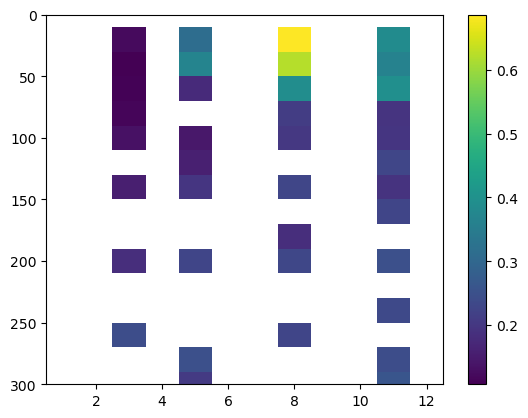

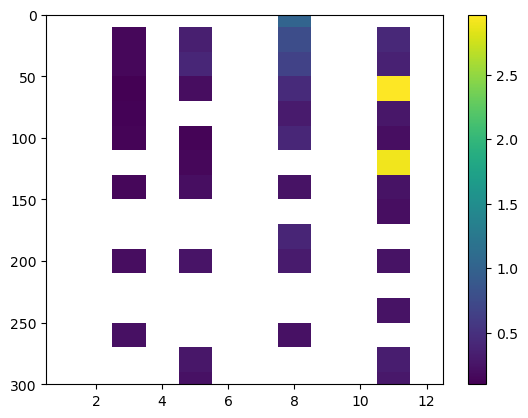

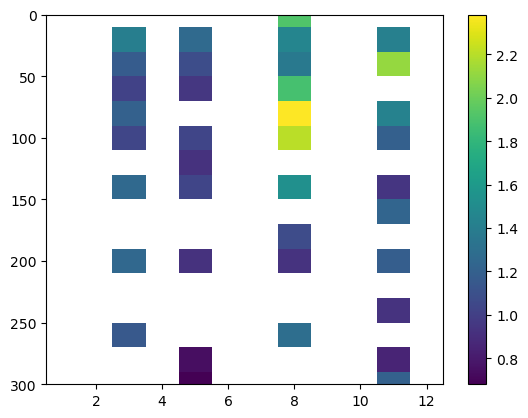

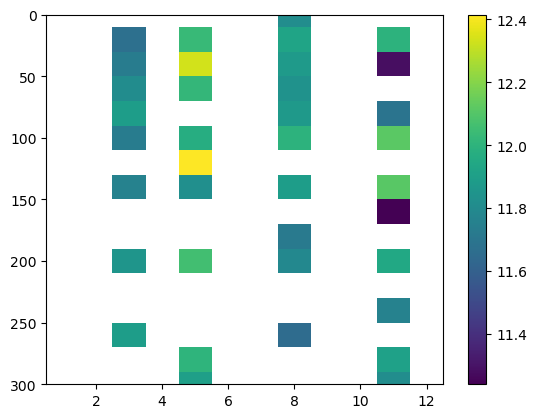

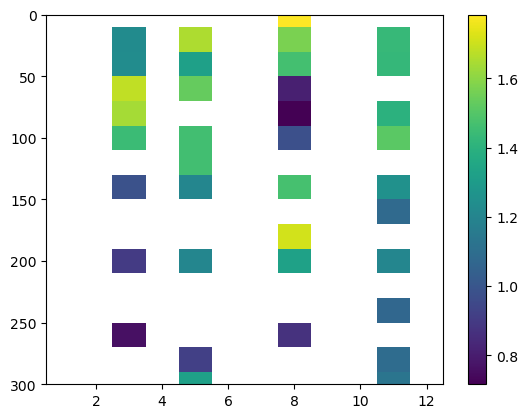

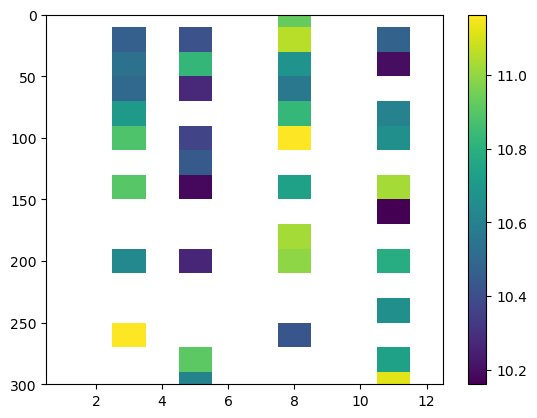

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['dissolved_Fe_bottle'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['dissolved_Fe_spec'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['ligand1_conc'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['ligand1_logK'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['ligand2_conc'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['ligand2_logK'].T)
plt.ylim(300,0)
plt.colorbar()


### SAVE

In [24]:
%%time
    
ds.to_netcdf('./bats_iron_monthly_climatology.nc')

CPU times: user 223 ms, sys: 110 ms, total: 333 ms
Wall time: 656 ms
